### 1. Understand the problem

### 2. Import the libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.xkcd()
import seaborn as sns
from sklearn import preprocessing
from sklearn.model_selection import train_test_split


### 3.Check the train data

In [2]:
dataset_train=pd.read_csv("/kaggle/input/titanic/train.csv")
dataset_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
dataset_test=pd.read_csv("/kaggle/input/titanic/test.csv")
dataset_test.head()


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [4]:
dataset_train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [5]:
dataset_test.isnull().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [6]:
dataset_train.shape

(891, 12)

In [7]:
dataset_test.shape

(418, 11)

### 4.Data Pre-processing

In [8]:
df_train=dataset_train.fillna(method="ffill")#fill the null values

In [9]:
df_test=dataset_test.fillna(method="ffill")

In [10]:
df_train.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          1
Embarked       0
dtype: int64

In [11]:
df_test.isnull().sum()

PassengerId     0
Pclass          0
Name            0
Sex             0
Age             0
SibSp           0
Parch           0
Ticket          0
Fare            0
Cabin          12
Embarked        0
dtype: int64

In [12]:
df_train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.00000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.58156,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.55459,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.42000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.00000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.00000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.00000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.00000,8.000000,6.000000,512.329200


In [13]:
df_test.describe()


,PassengerId,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,418.000000,418.000000,418.000000,418.000000
mean,1100.500000,2.265550,30.125000,0.447368,0.392344,35.560845
std,120.810458,0.841838,13.905601,0.896760,0.981429,55.856972
min,892.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,1.000000,22.000000,0.000000,0.000000,7.895800
50%,1100.500000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,3.000000,39.000000,1.000000,0.000000,31.471875
max,1309.000000,3.000000,76.000000,8.000000,9.000000,512.329200


In [14]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        890 non-null    object 
 11  Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [15]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          418 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         418 non-null    float64
 9   Cabin        406 non-null    object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.0+ KB


In [16]:
#label Encoding
label_encoder=preprocessing.LabelEncoder()

df_train['Pclass_type']=label_encoder.fit_transform(df_train["Pclass"])
df_train['Age_type']=label_encoder.fit_transform(df_train["Age"])
df_train['SibSp_type']=label_encoder.fit_transform(df_train["SibSp"])
df_train['Parch_type']=label_encoder.fit_transform(df_train["Parch"])
df_train['Fare_type']=label_encoder.fit_transform(df_train["Fare"])
df_train['Embarked_type']=label_encoder.fit_transform(df_train["Embarked"])
df_train['Sex_type']=label_encoder.fit_transform(df_train["Sex"])


In [17]:
label_encoder=preprocessing.LabelEncoder()

df_test['Pclass_type']=label_encoder.fit_transform(df_test["Pclass"])
df_test['Age_type']=label_encoder.fit_transform(df_test["Age"])
df_test['SibSp_type']=label_encoder.fit_transform(df_test["SibSp"])
df_test['Parch_type']=label_encoder.fit_transform(df_test["Parch"])
df_test['Fare_type']=label_encoder.fit_transform(df_test["Fare"])
df_test['Embarked_type']=label_encoder.fit_transform(df_test["Embarked"])
df_test['Sex_type']=label_encoder.fit_transform(df_test["Sex"])


In [18]:
#delete the unrequired columns
del df_train['PassengerId']
del df_train['Pclass']
del df_train['Age']
del df_train['Name']
del df_train['SibSp']
del df_train['Cabin']
del df_train['Parch']
del df_train['Fare']
del df_train['Ticket']
del df_train['Sex']
del df_train['Embarked']

In [19]:
del df_test['PassengerId']
del df_test['Pclass']
del df_test['Age']
del df_test['Name']
del df_test['SibSp']
del df_test['Cabin']
del df_test['Parch']
del df_test['Fare']
del df_test['Ticket']
del df_test['Sex']
del df_test['Embarked']

In [20]:
df_train.head()

,Survived,Pclass_type,Age_type,SibSp_type,Parch_type,Fare_type,Embarked_type,Sex_type
0,0,2,28,1,0,18,2,1
1,1,0,51,1,0,207,0,0
2,1,2,34,0,0,41,2,0
3,1,0,47,1,0,189,2,0
4,0,2,47,0,0,43,2,1


In [21]:
df_test.head()


,Pclass_type,Age_type,SibSp_type,Parch_type,Fare_type,Embarked_type,Sex_type
0,2,44,0,0,24,1,1
1,2,60,1,0,5,2,0
2,1,74,0,0,41,1,1
3,2,34,0,0,34,2,1
4,2,27,1,1,46,2,0


In [22]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Survived       891 non-null    int64
 1   Pclass_type    891 non-null    int64
 2   Age_type       891 non-null    int64
 3   SibSp_type     891 non-null    int64
 4   Parch_type     891 non-null    int64
 5   Fare_type      891 non-null    int64
 6   Embarked_type  891 non-null    int64
 7   Sex_type       891 non-null    int64
dtypes: int64(8)
memory usage: 55.8 KB


In [23]:
df_train.columns

Index(['Survived', 'Pclass_type', 'Age_type', 'SibSp_type', 'Parch_type',
       'Fare_type', 'Embarked_type', 'Sex_type'],
      dtype='object')

### split the data

In [24]:
#split the data into x and y
x=df_train[['Pclass_type', 'Age_type', 'SibSp_type','Parch_type', 'Fare_type', 'Embarked_type', 'Sex_type']]

y=df_train[['Survived']]

In [25]:
x

,Pclass_type,Age_type,SibSp_type,Parch_type,Fare_type,Embarked_type,Sex_type
0,2,28,1,0,18,2,1
1,0,51,1,0,207,0,0
2,2,34,0,0,41,2,0
3,0,47,1,0,189,2,0
4,2,47,0,0,43,2,1
...,...,...,...,...,...,...,...
886,1,35,0,0,85,2,1
887,0,24,0,0,153,2,0
888,2,24,1,2,131,2,0
889,0,34,0,0,153,0,1


In [26]:
y

,Survived
0,0
1,1
2,1
3,1
4,0
...,...
886,0
887,1
888,0
889,1


In [27]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3)

In [28]:
#scaled the x (train and test data)
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
scaled = scaler.fit_transform(df_train)


x_train_scaled = scaler.fit_transform(x_train) 
x_test_scaled=scaler.transform(x_test)
print("Mean value:",x_train_scaled.mean(axis=0))
print("SD value:",x_train_scaled.std(axis=0))

Mean value: [-1.71077705e-16  8.55388526e-18  8.55388526e-18  2.70873033e-17
 -4.27694263e-17 -1.71077705e-17  7.98362624e-17]
SD value: [1. 1. 1. 1. 1. 1. 1.]


### 6.Model selection and implimentation

In [29]:
from sklearn import tree

In [30]:
clf= tree.DecisionTreeClassifier()
clf= clf.fit(x_train_scaled,y_train)

In [31]:
clf.score(x_test_scaled,y_test)*100 #accuracy

75.3731343283582

In [32]:
predict= clf.predict(x_test_scaled)
print(predict)

[1 1 1 0 0 0 0 1 0 1 1 0 1 0 1 0 1 1 1 0 0 0 1 1 0 1 0 1 1 0 1 0 0 0 0 0 1
 0 0 0 1 0 1 0 0 0 1 0 0 0 1 0 1 1 0 0 0 0 0 0 1 0 0 0 0 1 1 1 0 0 0 1 0 0
 1 1 0 0 0 1 0 0 1 0 0 1 0 1 1 1 0 0 1 1 0 0 0 0 1 0 0 1 0 1 0 1 1 0 1 0 0
 1 1 0 0 1 1 0 0 0 0 0 0 0 1 0 0 0 0 0 1 1 1 0 1 1 0 1 0 0 1 1 0 1 0 0 1 0
 0 0 0 1 0 0 0 1 0 0 0 1 0 1 1 0 1 1 1 0 0 0 1 1 0 1 1 0 1 1 1 1 1 0 0 1 1
 1 1 0 0 0 1 0 1 1 0 1 1 1 0 0 1 0 0 0 1 0 1 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0
 0 0 1 0 0 1 0 0 0 0 1 0 1 1 0 0 0 0 1 0 0 0 1 0 1 0 0 1 0 0 1 1 0 1 0 0 0
 0 0 1 0 1 0 0 0 1]


In [33]:
from sklearn.metrics import mean_squared_error,mean_absolute_error
error = mean_absolute_error(predict,y_test)*100
error#error

24.62686567164179

### 7.EDA

In [34]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,predict)
cm

array([[130,  35],
       [ 31,  72]])

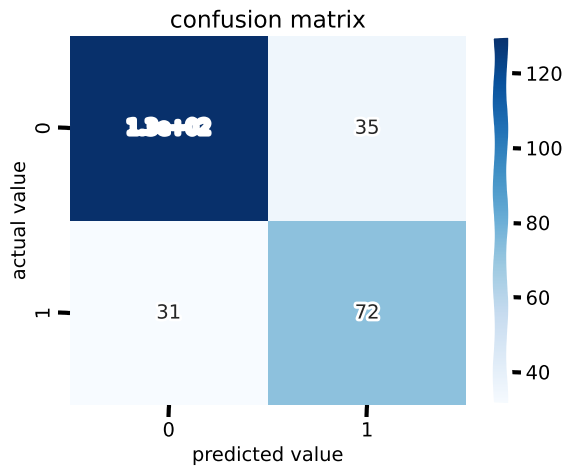

In [35]:
#visulization of confusion matrix
ax=sns.heatmap(cm,annot=True,cmap='Blues')
ax.set_title("confusion matrix")
ax.set_xlabel("predicted value")
ax.set_ylabel("actual value")
plt.show()

In [36]:
df_train['Survived'].value_counts()

0    549
1    342
Name: Survived, dtype: int64

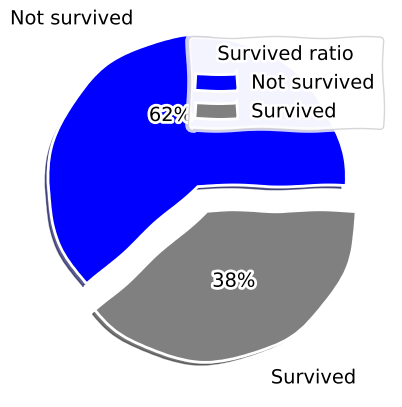

In [37]:
a = df_train['Survived'].value_counts()
labels = ['Not survived', 'Survived']
explode = [0.2,0] 
colors = ['blue', 'grey'] 
plt.pie(a, labels=labels, autopct='%1.0f%%', pctdistance=0.5, labeldistance=1.2, explode=explode, colors=colors, shadow = True) 

plt.legend(title = "Survived ratio")
plt.show() 

<AxesSubplot:xlabel='Survived', ylabel='Age_type'>

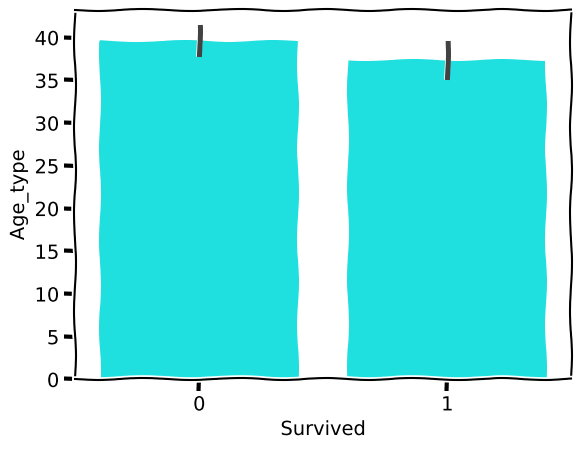

In [38]:
sns.barplot(x='Survived',y='Age_type',data=df_train,color='cyan',lw=4,ls='solid')

<AxesSubplot:xlabel='Survived', ylabel='Embarked_type'>

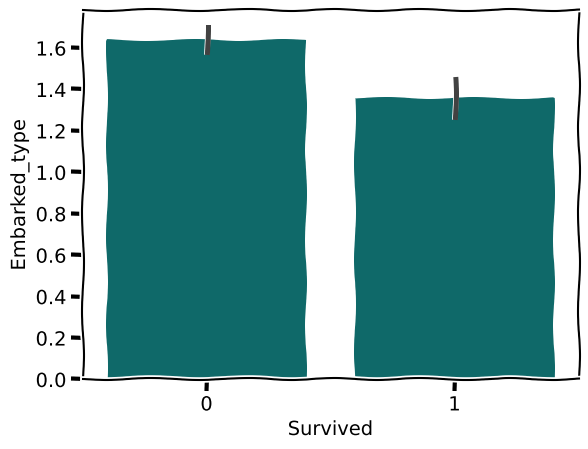

In [39]:
sns.barplot(x='Survived',y='Embarked_type',data=df_train,color='#007878',lw=4,ls='solid')

<AxesSubplot:xlabel='Age', ylabel='Fare'>

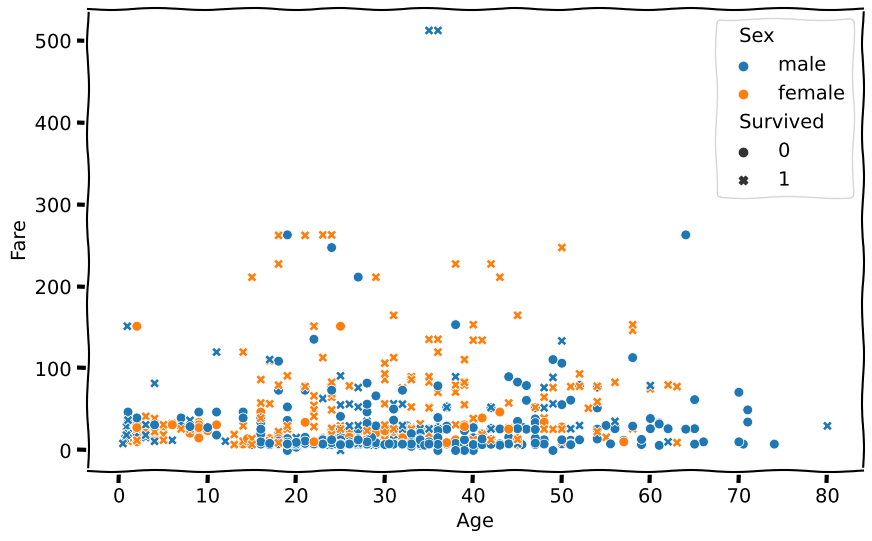

In [40]:
plt.figure(figsize=(10,6))#que
sns.scatterplot(x="Age",
                y="Fare",
                hue="Sex",
                style="Survived", #style of marker
                data=dataset_train,
                s=50)  #s = size of marker

In [41]:
Submission = clf.predict(df_test)
Submission

/opt/conda/lib/python3.7/site-packages/sklearn/base.py:444: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  f"X has feature names, but {self.__class__.__name__} was fitted without"


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,

In [42]:
pd.DataFrame({
    "Survived" : Submission
},columns=["Survived"])

,Survived
0,0
1,0
2,0
3,0
4,0
...,...
413,0
414,0
415,0
416,0


In [43]:
test1=pd.read_csv("/kaggle/input/titanic/test.csv")
test1.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [44]:
test2=test1["PassengerId"]
test2

0       892
1       893
2       894
3       895
4       896
       ... 
413    1305
414    1306
415    1307
416    1308
417    1309
Name: PassengerId, Length: 418, dtype: int64

In [45]:
fl = pd.DataFrame({
    "PassengerId":test2.values,
    "Survived" : Submission
},columns=["PassengerId","Survived"])
fl

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,0
...,...,...
413,1305,0
414,1306,0
415,1307,0
416,1308,0


In [46]:
fl.set_index("PassengerId", inplace=True)
fl.to_csv("submission.csv")

In [47]:
pd.read_csv("submission.csv")

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,0
...,...,...
413,1305,0
414,1306,0
415,1307,0
416,1308,0
